# DocID Generation POC: Residual Quantization for DSI

This notebook explores how MixLoRA-DSI generates document identifiers (DocIDs) using **Residual Quantization (RQ)**.

**Pipeline:**
1. Load news documents from CC-News
2. Encode documents using T5-base encoder -> 768-dim embeddings
3. Train a FAISS Residual Quantizer (M codebooks, K centroids each)
4. Extract RQ codes -> M-token DocIDs per document
5. Analyze DocID properties: uniqueness, clustering, temporal patterns

**Target:** A100 GPU.

---
## 0. Configuration

**Change `NUM_DOCS` below and the RQ parameters will auto-adjust.**

The key constraint: each codebook centroid needs enough training samples (~30-50 docs minimum).
So `K = 2^NBITS` must satisfy `NUM_DOCS / K >= 30`.

| NUM_DOCS | NBITS | K (centroids) | Docs/Centroid | Notes |
|----------|-------|---------------|---------------|-------|
| 100      | 2     | 4             | 25            | Toy demo |
| 1,000    | 4     | 16            | 62            | Small POC |
| 5,000    | 6     | 64            | 78            | Medium POC |
| 10,000   | 8     | 256           | 39            | Good exploration |
| 50,000   | 9     | 512           | 97            | |
| 100,000  | 10    | 1024          | 97            | |
| 300,000+ | 11    | 2048          | 146+          | MixLoRA-DSI default |

In [1]:
# ============================================================
#  CONFIGURATION — Change these values and re-run everything
# ============================================================

NUM_DOCS = 10_000          # Number of documents to sample
M = 8                      # Number of codebooks (= DocID length). 8 is MixLoRA-DSI default.
NBITS = None               # Bits per codebook. None = auto-select based on NUM_DOCS.
BATCH_SIZE = 64            # Encoding batch size (lower if you run out of GPU memory)
MAX_LENGTH = 256           # Max tokens per document (MixLoRA-DSI default)
MODEL_NAME = "t5-base"     # Encoder model
SEED = 42

In [2]:
# ============================================================
#  Auto-select NBITS based on NUM_DOCS
# ============================================================
#
# Rule: we want NUM_DOCS / K >= ~30 so each centroid gets
# enough training samples. K = 2^NBITS.
#
# We also want K^M >> NUM_DOCS for DocID uniqueness.
# With M=8 even K=4 gives 4^8 = 65K possible IDs, so uniqueness
# is rarely the bottleneck — training quality is.

MIN_DOCS_PER_CENTROID = 30

def auto_select_nbits(num_docs, min_docs_per_centroid=MIN_DOCS_PER_CENTROID):
    """Pick the largest NBITS such that num_docs / 2^nbits >= min_docs_per_centroid."""
    import math
    max_k = num_docs / min_docs_per_centroid
    nbits = int(math.floor(math.log2(max(max_k, 2))))
    nbits = max(2, min(nbits, 12))  # Clamp to [2, 12]
    return nbits

if NBITS is None:
    NBITS = auto_select_nbits(NUM_DOCS)

K = 2 ** NBITS              # Centroids per codebook
T5_VOCAB_SIZE = 32100       # Original T5 vocabulary size

print("=" * 55)
print("  CONFIGURATION")
print("=" * 55)
print(f"  Documents:            {NUM_DOCS:>10,}")
print(f"  Codebooks (M):        {M:>10}")
print(f"  Bits per codebook:    {NBITS:>10}")
print(f"  Centroids (K=2^bits): {K:>10,}")
print(f"  Docs per centroid:    {NUM_DOCS / K:>10.0f}")
print(f"  Possible DocIDs (K^M):{K**M:>10.2e}")
print(f"  New vocab tokens:     {M * K:>10,}")
print(f"  Total vocab:          {T5_VOCAB_SIZE + M * K:>10,}")
print(f"  Encoder model:        {MODEL_NAME:>10}")
print(f"  Max token length:     {MAX_LENGTH:>10}")
print(f"  Batch size:           {BATCH_SIZE:>10}")
print("=" * 55)

if NUM_DOCS / K < 20:
    print(f"\n  WARNING: Only {NUM_DOCS / K:.0f} docs per centroid — "
          f"RQ training may be poor. Consider lowering NBITS or raising NUM_DOCS.")
if NUM_DOCS / K > 500:
    print(f"\n  NOTE: {NUM_DOCS / K:.0f} docs per centroid is generous — "
          f"you could raise NBITS for finer quantization.")

  CONFIGURATION
  Documents:                10,000
  Codebooks (M):                 8
  Bits per codebook:             8
  Centroids (K=2^bits):        256
  Docs per centroid:            39
  Possible DocIDs (K^M):  1.84e+19
  New vocab tokens:          2,048
  Total vocab:              34,148
  Encoder model:           t5-base
  Max token length:            256
  Batch size:                   64


## 1. Setup

In [3]:
# Install dependencies if needed (uncomment on first run)
!pip install -q transformers torch pandas numpy matplotlib seaborn scikit-learn tqdm
!pip install -q faiss-gpu-cu12


In [4]:
import os
import json
import time
import math
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
from transformers import T5Model, T5Tokenizer, T5ForConditionalGeneration
from datasets import load_dataset
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## 2. Load & Sample Documents

In [5]:
# Load CC-News directly from HuggingFace
# Uses streaming to avoid downloading the full 1.1GB dataset when we only need a sample

print(f"Loading CC-News from HuggingFace (streaming, sampling {NUM_DOCS:,} docs)...")
t0 = time.time()

if NUM_DOCS <= 50_000:
    # Stream and take only what we need — much faster for small samples
    ds = load_dataset("vblagoje/cc_news", split="train", streaming=True)
    # Shuffle with a buffer for some randomness, then take NUM_DOCS * 1.2 to allow filtering
    n_fetch = int(NUM_DOCS * 1.3)
    rows = []
    for i, row in enumerate(ds.shuffle(seed=SEED, buffer_size=10_000)):
        if i >= n_fetch:
            break
        rows.append(row)
    df_raw = pd.DataFrame(rows)
else:
    # For large samples, download the full dataset (faster than streaming 100K+)
    ds = load_dataset("vblagoje/cc_news", split="train")
    df_raw = ds.to_pandas()

print(f"Fetched {len(df_raw):,} rows in {time.time() - t0:.1f}s")
print(f"Columns: {list(df_raw.columns)}")

Loading CC-News from HuggingFace (streaming, sampling 10,000 docs)...
Fetched 13,000 rows in 12.9s
Columns: ['title', 'text', 'domain', 'date', 'description', 'url', 'image_url']


In [6]:
# Clean and sample
df_raw["date_parsed"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_valid = df_raw.dropna(subset=["date_parsed", "text"]).copy()
df_valid = df_valid[df_valid["text"].str.len() > 100]
print(f"Valid articles (with date + text > 100 chars): {len(df_valid):,}")

n = min(NUM_DOCS, len(df_valid))
if n < NUM_DOCS:
    print(f"WARNING: Only {n:,} valid articles available, using all of them.")

# Stratified sample by year-month to preserve temporal distribution
df_valid["year_month"] = df_valid["date_parsed"].dt.to_period("M")
df_sample = df_valid.groupby("year_month", group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, int(n * len(x) / len(df_valid)))),
                       random_state=SEED)
).reset_index(drop=True)

if len(df_sample) > n:
    df_sample = df_sample.sample(n, random_state=SEED).reset_index(drop=True)

print(f"\nSampled {len(df_sample):,} documents")
print(f"Date range: {df_sample['date_parsed'].min().date()} to {df_sample['date_parsed'].max().date()}")
print(f"\nDocuments per year-month:")
print(df_sample["year_month"].value_counts().sort_index())

# Free the raw data
del df_raw, df_valid

Valid articles (with date + text > 100 chars): 11,985

Sampled 9,992 documents
Date range: 2017-01-01 to 2018-07-20

Documents per year-month:
year_month
2017-01     401
2017-02     685
2017-03      22
2017-04     738
2017-05       2
2017-06     496
2017-07       4
2017-08    1058
2017-09      13
2017-10     761
2017-11       3
2017-12    1010
2018-01      19
2018-02    1212
2018-03     895
2018-04    1097
2018-05    1010
2018-06       5
2018-07     561
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_27841/3989210775.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_valid.groupby("year_month", group_keys=False).apply(


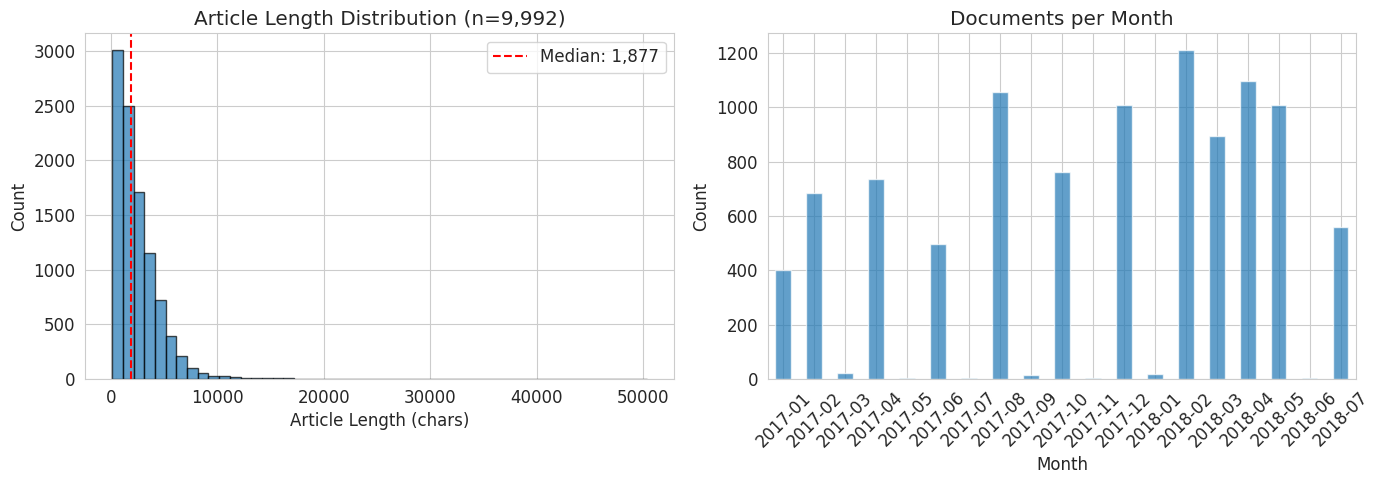

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_lengths = df_sample['text'].str.len()
axes[0].hist(text_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Article Length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Article Length Distribution (n={len(df_sample):,})')
axes[0].axvline(text_lengths.median(), color='red', linestyle='--',
                label=f'Median: {text_lengths.median():,.0f}')
axes[0].legend()

df_sample.groupby(df_sample['date_parsed'].dt.to_period('M')).size().plot(
    kind='bar', ax=axes[1], alpha=0.7)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_title('Documents per Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Generate Document Embeddings with T5

Use the **T5-base encoder** to produce 768-dim document embeddings.
Documents are truncated to `MAX_LENGTH` tokens (default 256).

In [8]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
t5_model = T5Model.from_pretrained(MODEL_NAME).to(device).eval()

print(f"Model: {MODEL_NAME}")
print(f"Hidden size: {t5_model.config.d_model}")
print(f"Parameters: {sum(p.numel() for p in t5_model.parameters()):,}")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Model: t5-base
Hidden size: 768
Parameters: 222,903,552


In [9]:
def encode_documents(texts, model, tokenizer, max_length, batch_size):
    """Encode documents using T5 encoder -> first-token hidden state (768-dim)."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch, max_length=max_length, padding=True,
            truncation=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            out = model.encoder(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                return_dict=True
            )
            # First token as document embedding (same idea as T5DenseEncoder)
            all_embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)

doc_texts = [
    f"{row['title']}. {row['text']}" if pd.notna(row['title']) else row['text']
    for _, row in df_sample.iterrows()
]

print(f"Encoding {len(doc_texts):,} documents (batch_size={BATCH_SIZE}, max_length={MAX_LENGTH})...")
t0 = time.time()
doc_embeddings = encode_documents(doc_texts, t5_model, tokenizer, MAX_LENGTH, BATCH_SIZE)
elapsed = time.time() - t0

print(f"Done in {elapsed:.1f}s ({len(doc_texts)/elapsed:.0f} docs/sec)")
print(f"Shape: {doc_embeddings.shape}, dtype: {doc_embeddings.dtype}, "
      f"memory: {doc_embeddings.nbytes / 1e6:.1f} MB")

Encoding 9,992 documents (batch_size=64, max_length=256)...


Encoding:   0%|          | 0/157 [00:00<?, ?it/s]

Done in 37.3s (268 docs/sec)
Shape: (9992, 768), dtype: float32, memory: 30.7 MB


In [10]:
# Free GPU memory — we don't need the encoder anymore
del t5_model
torch.cuda.empty_cache()

Norms — min: 1.375, max: 9.284, mean: 7.804
NaN: 0, Inf: 0


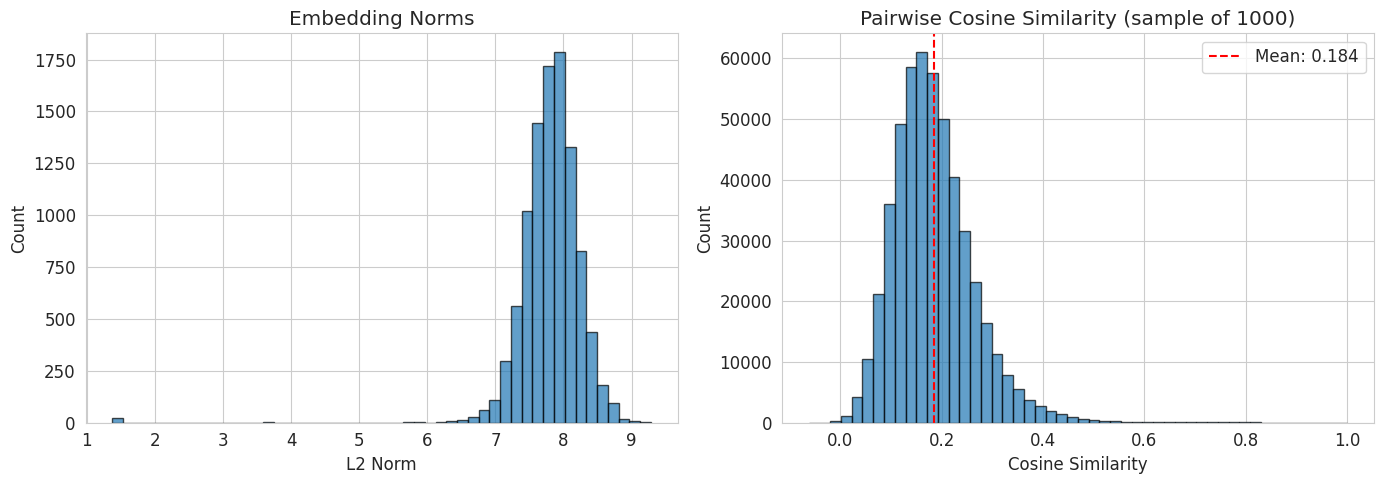

In [11]:
# Sanity check
norms = np.linalg.norm(doc_embeddings, axis=1)
print(f"Norms — min: {norms.min():.3f}, max: {norms.max():.3f}, "
      f"mean: {norms.mean():.3f}")
print(f"NaN: {np.isnan(doc_embeddings).sum()}, Inf: {np.isinf(doc_embeddings).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(norms, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('L2 Norm')
axes[0].set_ylabel('Count')
axes[0].set_title('Embedding Norms')

# Pairwise cosine similarity on a subsample
sub = np.random.choice(len(doc_embeddings), min(1000, len(doc_embeddings)), replace=False)
cos_sim = cosine_similarity(doc_embeddings[sub])
upper = cos_sim[np.triu_indices_from(cos_sim, k=1)]
axes[1].hist(upper, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Pairwise Cosine Similarity (sample of {len(sub)})')
axes[1].axvline(upper.mean(), color='red', linestyle='--', label=f'Mean: {upper.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Residual Quantization — Build the Index

**How RQ works (different from PQ!):**
1. Codebook C1 quantizes the **full** vector -> code[0]. Compute residual r1 = x - C1[code[0]].
2. Codebook C2 quantizes the **residual** r1 -> code[1]. Compute r2 = r1 - C2[code[1]].
3. ... repeat for M codebooks. Each codebook refines the previous approximation.

This produces M integer codes per document. Together they form the DocID.

In [12]:
d = doc_embeddings.shape[1]  # 768

print(f"Training RQ index: d={d}, M={M}, nbits={NBITS} (K={K})")
print(f"  {len(doc_embeddings):,} docs / {K} centroids = "
      f"{len(doc_embeddings)/K:.0f} docs per centroid")

t0 = time.time()
rq_index = faiss.IndexResidualQuantizer(d, M, NBITS, faiss.METRIC_INNER_PRODUCT)
rq_index.verbose = True
rq_index.train(doc_embeddings)
rq_index.add(doc_embeddings)
print(f"\nDone in {time.time() - t0:.1f}s — index has {rq_index.ntotal} vectors")

Training RQ index: d=768, M=8, nbits=8 (K=256)
  9,992 docs / 256 centroids = 39 docs per centroid

Done in 103.5s — index has 9992 vectors


## 5. Extract RQ Codes (DocIDs)

Each document is now represented by M integer codes (one per codebook).
This uses the same bitstring extraction as MixLoRA-DSI's `create_customized_smtid_file.py`.

In [13]:
def extract_rq_codes(rq_index, embeddings, m, nbits):
    """Extract RQ codes — mirrors create_customized_smtid_file.py."""
    rq = rq_index.rq
    uint8_codes = rq.compute_codes(embeddings)
    doc_codes = []
    for u8_code in tqdm(uint8_codes, desc="Extracting RQ codes"):
        bs = faiss.BitstringReader(faiss.swig_ptr(u8_code), uint8_codes.shape[1])
        doc_codes.append([bs.read(nbits) for _ in range(m)])
    return np.array(doc_codes)

doc_codes = extract_rq_codes(rq_index, doc_embeddings, M, NBITS)
print(f"Codes shape: {doc_codes.shape}")
print(f"Code range: [{doc_codes.min()}, {doc_codes.max()}] (expected [0, {K-1}])")
print(f"\nFirst 5 DocIDs:")
for i in range(5):
    print(f"  Doc {i}: {doc_codes[i].tolist()}")

Extracting RQ codes:   0%|          | 0/9992 [00:00<?, ?it/s]

Codes shape: (9992, 8)
Code range: [0, 255] (expected [0, 255])

First 5 DocIDs:
  Doc 0: [42, 132, 219, 32, 80, 176, 31, 71]
  Doc 1: [157, 191, 161, 221, 206, 220, 143, 182]
  Doc 2: [46, 246, 172, 139, 65, 9, 65, 199]
  Doc 3: [62, 4, 50, 238, 83, 89, 138, 159]
  Doc 4: [113, 103, 160, 176, 81, 184, 106, 138]


## 6. Map to T5 Token IDs (SMTID)

MixLoRA-DSI extends the T5 vocabulary with `M * K` new tokens.
Each decoding step i predicts from codebook i's token range:

```
token_id[i] = 32100 + K * i + code[i]
```

In [14]:
offsets = np.arange(M) * K + T5_VOCAB_SIZE
smtids = doc_codes + offsets[np.newaxis, :]

print(f"Vocabulary layout (T5_VOCAB_SIZE={T5_VOCAB_SIZE}, K={K}, M={M}):")
print(f"  Original T5 vocab:  [0, {T5_VOCAB_SIZE - 1}]")
for i in range(M):
    lo = T5_VOCAB_SIZE + K * i
    hi = T5_VOCAB_SIZE + K * (i + 1) - 1
    print(f"  Codebook {i}:         [{lo}, {hi}]")
print(f"  Total vocab size:   {T5_VOCAB_SIZE + M * K}")
print(f"\nFirst 3 SMTIDs: {smtids[:3].tolist()}")

Vocabulary layout (T5_VOCAB_SIZE=32100, K=256, M=8):
  Original T5 vocab:  [0, 32099]
  Codebook 0:         [32100, 32355]
  Codebook 1:         [32356, 32611]
  Codebook 2:         [32612, 32867]
  Codebook 3:         [32868, 33123]
  Codebook 4:         [33124, 33379]
  Codebook 5:         [33380, 33635]
  Codebook 6:         [33636, 33891]
  Codebook 7:         [33892, 34147]
  Total vocab size:   34148

First 3 SMTIDs: [[32142, 32488, 32831, 32900, 33204, 33556, 33667, 33963], [32257, 32547, 32773, 33089, 33330, 33600, 33779, 34074], [32146, 32602, 32784, 33007, 33189, 33389, 33701, 34091]]


## 7. Uniqueness & Collision Analysis

In [15]:
docid_strings = ["_".join(str(c) for c in row) for row in doc_codes]
n_total = len(docid_strings)
n_unique = len(set(docid_strings))

print(f"Total documents:  {n_total:,}")
print(f"Unique DocIDs:    {n_unique:,}")
print(f"Collisions:       {n_total - n_unique:,} ({(n_total - n_unique)/n_total*100:.2f}%)")
print(f"Uniqueness rate:  {n_unique/n_total*100:.2f}%")

# Collision group sizes
docid_counts = Counter(docid_strings)
sizes = np.array(list(docid_counts.values()))
print(f"\nGroup size percentiles: "
      f"{np.quantile(sizes, [0, .5, .75, .9, .99, 1]).astype(int).tolist()}")

worst = [(did, c) for did, c in docid_counts.most_common(5) if c > 1]
if worst:
    print(f"\nWorst collisions:")
    for did, c in worst:
        print(f"  DocID {did}: {c} documents")

Total documents:  9,992
Unique DocIDs:    9,258
Collisions:       734 (7.35%)
Uniqueness rate:  92.65%

Group size percentiles: [1, 1, 1, 1, 3, 25]

Worst collisions:
  DocID 72_191_125_41_35_211_111_168: 25 documents
  DocID 49_163_128_54_3_195_184_168: 6 documents
  DocID 129_238_247_41_35_184_111_43: 5 documents
  DocID 136_43_207_254_145_40_243_238: 5 documents
  DocID 95_90_136_112_160_228_111_227: 5 documents


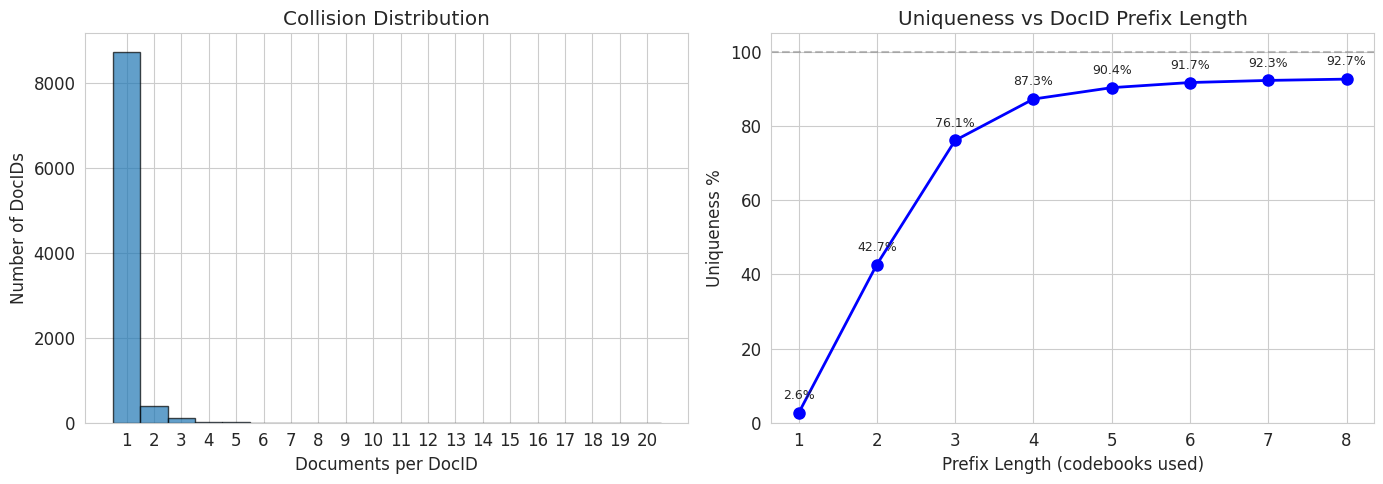

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collision histogram
max_sz = min(int(sizes.max()), 20)
axes[0].hist(sizes, bins=range(1, max_sz + 2), edgecolor='black', alpha=0.7, align='left')
axes[0].set_xlabel('Documents per DocID')
axes[0].set_ylabel('Number of DocIDs')
axes[0].set_title('Collision Distribution')
axes[0].set_xticks(range(1, max_sz + 1))

# Progressive uniqueness by prefix length
prefix_unique = []
for plen in range(1, M + 1):
    prefixes = ["_".join(str(c) for c in row[:plen]) for row in doc_codes]
    prefix_unique.append(len(set(prefixes)) / n_total * 100)

axes[1].plot(range(1, M + 1), prefix_unique, 'bo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Prefix Length (codebooks used)')
axes[1].set_ylabel('Uniqueness %')
axes[1].set_title('Uniqueness vs DocID Prefix Length')
axes[1].set_xticks(range(1, M + 1))
axes[1].set_ylim(0, 105)
axes[1].axhline(100, color='gray', linestyle='--', alpha=0.5)
for i, pct in enumerate(prefix_unique):
    axes[1].annotate(f'{pct:.1f}%', (i + 1, pct), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Codebook Usage

CB   Used     K        Usage%    Entropy   MaxCnt  
0    256      256      100.0     7.74      198     
1    237      256      92.6      6.35      2051    
2    256      256      100.0     7.56      505     
3    256      256      100.0     7.58      387     
4    256      256      100.0     7.61      317     
5    256      256      100.0     7.59      274     
6    256      256      100.0     7.68      247     
7    256      256      100.0     7.73      241     


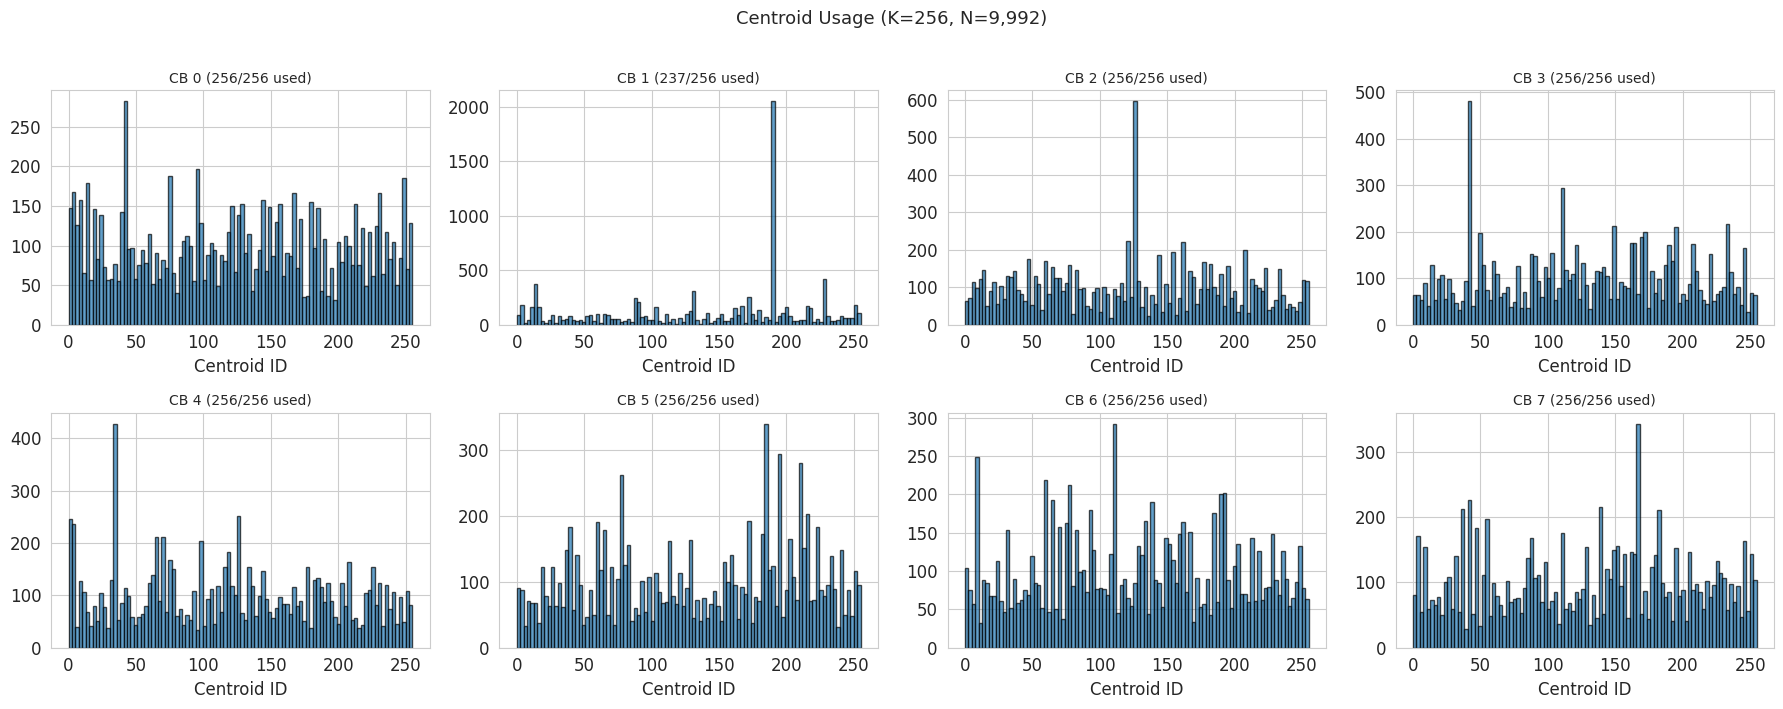

In [17]:
n_cols = min(M, 4)
n_rows = math.ceil(M / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
if M == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes).flatten()

print(f"{'CB':<4} {'Used':<8} {'K':<8} {'Usage%':<9} {'Entropy':<9} {'MaxCnt':<8}")
for cb in range(M):
    codes_cb = doc_codes[:, cb]
    counts = np.bincount(codes_cb, minlength=K)
    used = int(np.sum(counts > 0))
    probs = counts[counts > 0] / counts.sum()
    entropy = -np.sum(probs * np.log2(probs))
    print(f"{cb:<4} {used:<8} {K:<8} {used/K*100:<9.1f} {entropy:<9.2f} {int(counts.max()):<8}")

    axes[cb].hist(codes_cb, bins=min(100, used), edgecolor='black', alpha=0.7)
    axes[cb].set_title(f'CB {cb} ({used}/{K} used)', fontsize=10)
    axes[cb].set_xlabel('Centroid ID')

for i in range(M, len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Centroid Usage (K={K}, N={n_total:,})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Hierarchical Clustering Structure

The first codebook captures coarse structure — let's see if those clusters are semantically coherent.

In [18]:
first_codes = doc_codes[:, 0]
cluster_counts = Counter(first_codes)
top_clusters = cluster_counts.most_common(10)

print(f"Top 10 first-level clusters:")
print(f"{'Cluster':<10} {'Size':<8} {'Sample Titles'}")
print("-" * 100)
for cid, cnt in top_clusters:
    mask = first_codes == cid
    titles = df_sample.loc[mask, 'title'].dropna().head(3).tolist()
    print(f"{cid:<10} {cnt:<8} {' | '.join(t[:40] for t in titles)[:90]}")

Top 10 first-level clusters:
Cluster    Size     Sample Titles
----------------------------------------------------------------------------------------------------
41         198      Dean Elgar scores ton as South Africa ge | Brian Hoyer Hopes To Return With Bears | Jeff K
95         165      Reggie Bush Finishes Season With Negativ | Novak Djokovic slow out of the blocks bu | Harp
15         111      France calls for Russia to stop military | Russian snowboard World Cup events cance | Finl
129        106      Eric Decker Posts Sweet Message About Be | Jamie Lynn Spears' Daughter Maddie Aldri | Paul
249        105      Yellowknife's St Patrick's flea market f | Shreveport group to protest southern Lou | Anti
74         104      Richmond's Urban Remedy to roll out new  | Edmonton police seek witnesses after roa | Laur
118        97       Istanbul nightclub attack: Islamic State | Toronto police search for missing teen b | Ista
39         91       ZTE Blade V8 Pro review: A decent phone

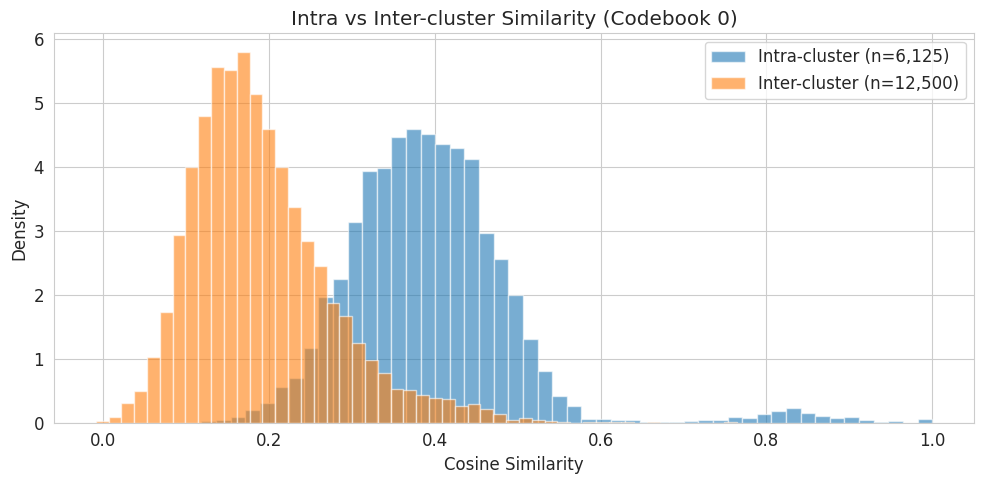

Intra: mean=0.394  Inter: mean=0.190  Gap: 0.204


In [19]:
# Intra-cluster vs inter-cluster similarity
top_5 = [c for c, _ in cluster_counts.most_common(5)]
intra, inter = [], []

for cid in top_5:
    mask = first_codes == cid
    ce = doc_embeddings[mask]
    if len(ce) > 1:
        s = ce[:min(50, len(ce))]
        sim = cosine_similarity(s)
        intra.extend(sim[np.triu_indices_from(sim, k=1)])
    oe = doc_embeddings[~mask]
    so = oe[np.random.choice(len(oe), min(50, len(oe)), replace=False)]
    cross = cosine_similarity(ce[:min(50, len(ce))], so)
    inter.extend(cross.flatten())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(intra, bins=50, alpha=0.6, label=f'Intra-cluster (n={len(intra):,})', density=True)
ax.hist(inter, bins=50, alpha=0.6, label=f'Inter-cluster (n={len(inter):,})', density=True)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Intra vs Inter-cluster Similarity (Codebook 0)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Intra: mean={np.mean(intra):.3f}  Inter: mean={np.mean(inter):.3f}  "
      f"Gap: {np.mean(intra) - np.mean(inter):.3f}")

## 10. Temporal Analysis

Do documents from the same time period end up with similar DocIDs?
Important for understanding how forgetting old DocIDs affects retrieval.

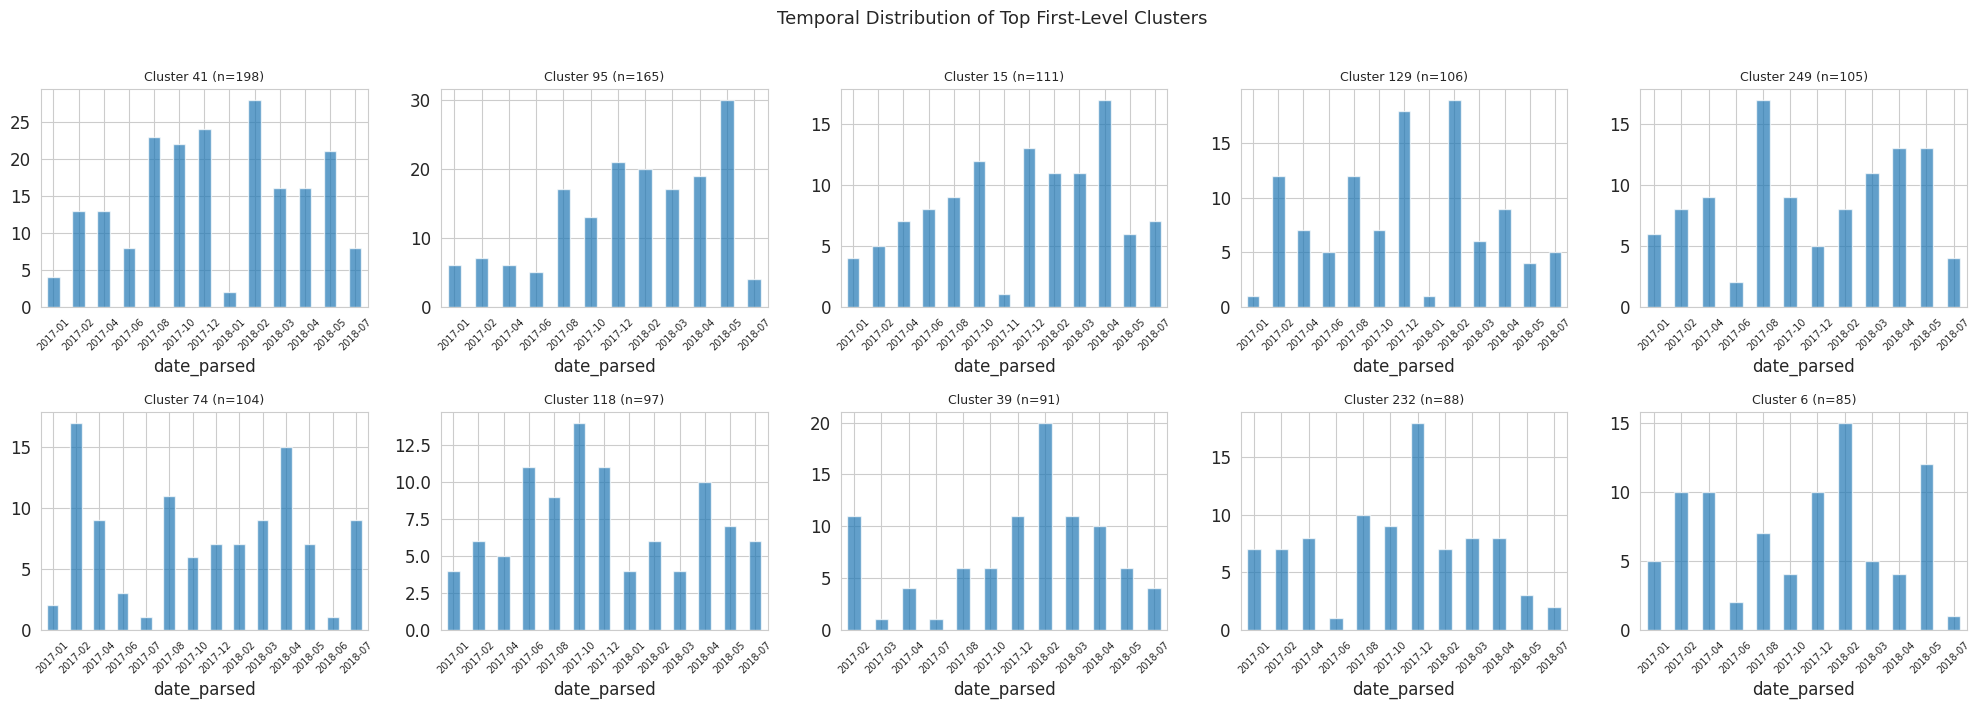

In [20]:
df_sample['first_code'] = first_codes

# Temporal distribution of top clusters
top_10 = [c for c, _ in cluster_counts.most_common(10)]
n_show = min(10, len(top_10))
n_cols_t = min(5, n_show)
n_rows_t = math.ceil(n_show / n_cols_t)

fig, axes = plt.subplots(n_rows_t, n_cols_t, figsize=(4 * n_cols_t, 3.5 * n_rows_t))
axes = np.atleast_2d(axes).flatten() if n_show > 1 else [axes]

for idx, cid in enumerate(top_10[:n_show]):
    cdocs = df_sample[df_sample['first_code'] == cid]
    cdocs.groupby(cdocs['date_parsed'].dt.to_period('M')).size().plot(
        kind='bar', ax=axes[idx], alpha=0.7)
    axes[idx].set_title(f'Cluster {cid} (n={len(cdocs)})', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Temporal Distribution of Top First-Level Clusters', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

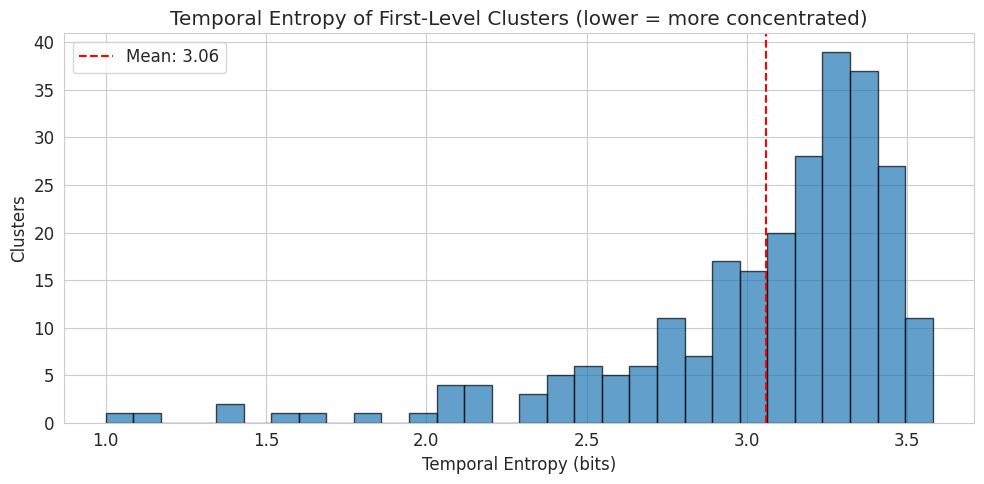

In [21]:
# Temporal entropy per cluster — lower = more temporally concentrated
entropies = []
for cid, cnt in cluster_counts.items():
    if cnt < 5:
        continue
    cdocs = df_sample[df_sample['first_code'] == cid]
    mc = cdocs.groupby(cdocs['date_parsed'].dt.to_period('M')).size()
    p = mc.values / mc.sum()
    entropies.append(-np.sum(p * np.log2(p + 1e-10)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(entropies, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Temporal Entropy (bits)')
ax.set_ylabel('Clusters')
ax.set_title('Temporal Entropy of First-Level Clusters (lower = more concentrated)')
ax.axvline(np.mean(entropies), color='red', linestyle='--', label=f'Mean: {np.mean(entropies):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Reconstruction Quality

Relative L2 Error:    mean=0.4859, std=0.1027
Cosine Similarity:    mean=0.8675, std=0.0587


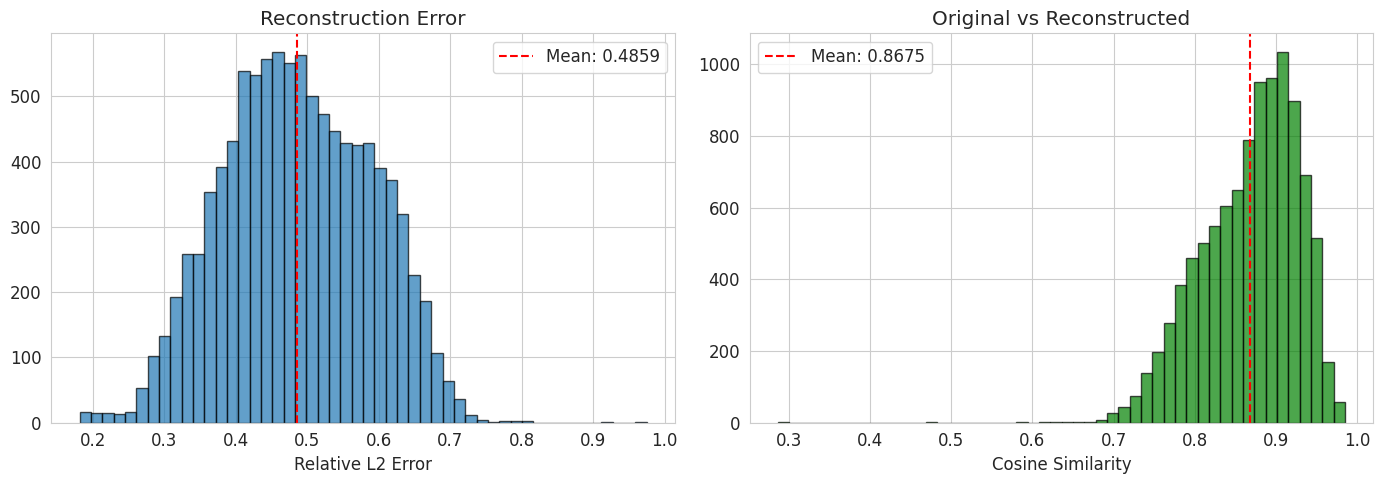

In [22]:
reconstructed = rq_index.reconstruct_n(0, len(doc_embeddings))

errors = np.linalg.norm(doc_embeddings - reconstructed, axis=1)
rel_errors = errors / norms
dot = np.sum(doc_embeddings * reconstructed, axis=1)
recon_norms = np.linalg.norm(reconstructed, axis=1)
cos_sims = dot / (norms * recon_norms + 1e-10)

print(f"Relative L2 Error:    mean={rel_errors.mean():.4f}, std={rel_errors.std():.4f}")
print(f"Cosine Similarity:    mean={cos_sims.mean():.4f}, std={cos_sims.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(rel_errors, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Relative L2 Error')
axes[0].set_title('Reconstruction Error')
axes[0].axvline(rel_errors.mean(), color='red', linestyle='--', label=f'Mean: {rel_errors.mean():.4f}')
axes[0].legend()

axes[1].hist(cos_sims, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_title('Original vs Reconstructed')
axes[1].axvline(cos_sims.mean(), color='red', linestyle='--', label=f'Mean: {cos_sims.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. t-SNE Visualization

In [23]:
N_TSNE = min(3000, len(doc_embeddings))
idx = np.random.choice(len(doc_embeddings), N_TSNE, replace=False)

print(f"Running t-SNE on {N_TSNE} samples...")
t0 = time.time()
tsne_xy = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(doc_embeddings[idx])
print(f"Done in {time.time() - t0:.1f}s")

tsne_codes = doc_codes[idx, 0]
tsne_dates = df_sample.iloc[idx]['date_parsed']

Running t-SNE on 3000 samples...
Done in 9.1s


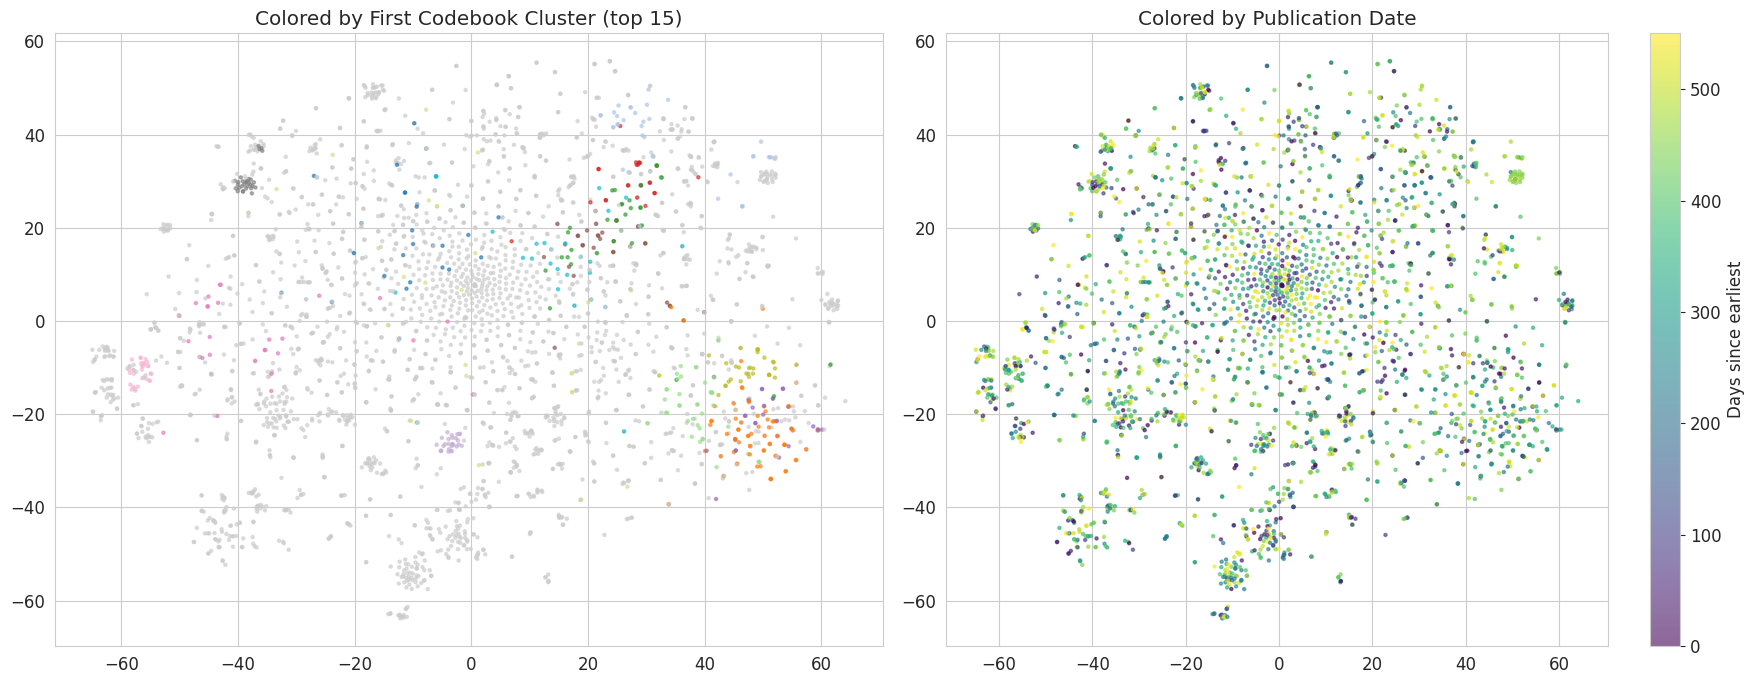

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# By cluster
top15 = set(c for c, _ in Counter(tsne_codes).most_common(15))
c2i = {c: i for i, c in enumerate(sorted(top15))}
cmap = plt.cm.tab20
colors = [cmap(c2i[c] / 15) if c in c2i else (0.8, 0.8, 0.8, 0.3) for c in tsne_codes]

axes[0].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=colors, s=5, alpha=0.6)
axes[0].set_title('Colored by First Codebook Cluster (top 15)')

# By date
day_nums = (tsne_dates - tsne_dates.min()).dt.days.values
sc = axes[1].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=day_nums, s=5, alpha=0.6, cmap='viridis')
axes[1].set_title('Colored by Publication Date')
plt.colorbar(sc, ax=axes[1], label='Days since earliest')

plt.tight_layout()
plt.show()

## 13. Compare RQ Configurations

Sweep over different (M, NBITS) combos around the auto-selected config to see tradeoffs.
We keep the constraint `NUM_DOCS / K >= 10` to avoid useless configs.

In [25]:
# Generate sensible comparison configs based on NUM_DOCS
max_nbits = int(math.floor(math.log2(max(NUM_DOCS / 10, 4))))  # At least 10 docs per centroid
max_nbits = min(max_nbits, 12)
min_nbits = max(2, NBITS - 3)

comparison_configs = []
for nb in sorted(set([min_nbits, NBITS - 1, NBITS, min(NBITS + 1, max_nbits), min(NBITS + 2, max_nbits)])):
    if nb < 2 or nb > max_nbits:
        continue
    k_test = 2 ** nb
    if NUM_DOCS / k_test < 10:
        continue
    is_default = (nb == NBITS)
    label = f"M={M}, K={k_test}" + (" *" if is_default else "")
    comparison_configs.append((M, nb, label))

# Also try different M values at the auto-selected NBITS
for m_test in [4, 12, 16]:
    if m_test != M:
        label = f"M={m_test}, K={K}"
        comparison_configs.append((m_test, NBITS, label))

# Deduplicate
comparison_configs = list({(m, nb): (m, nb, lbl) for m, nb, lbl in comparison_configs}.values())
comparison_configs.sort(key=lambda x: (x[0], x[1]))

print(f"Comparing {len(comparison_configs)} configs (* = current):")
for m_, nb_, lbl in comparison_configs:
    print(f"  {lbl}  (docs/centroid = {NUM_DOCS / 2**nb_:.0f})")

Comparing 7 configs (* = current):
  M=4, K=256  (docs/centroid = 39)
  M=8, K=32  (docs/centroid = 312)
  M=8, K=128  (docs/centroid = 78)
  M=8, K=256 *  (docs/centroid = 39)
  M=8, K=512  (docs/centroid = 20)
  M=12, K=256  (docs/centroid = 39)
  M=16, K=256  (docs/centroid = 39)


In [26]:
results = []

for m_, nb_, label in comparison_configs:
    k_ = 2 ** nb_
    print(f"Training: {label}...", end=" ")
    rq = faiss.IndexResidualQuantizer(d, m_, nb_, faiss.METRIC_INNER_PRODUCT)
    rq.verbose = False
    rq.train(doc_embeddings)
    rq.add(doc_embeddings)

    # Extract codes
    rq_obj = rq.rq
    u8 = rq_obj.compute_codes(doc_embeddings)
    codes = []
    for row in u8:
        bs = faiss.BitstringReader(faiss.swig_ptr(row), u8.shape[1])
        codes.append([bs.read(nb_) for _ in range(m_)])
    codes = np.array(codes)

    strs = ["_".join(str(c) for c in r) for r in codes]
    uniq = len(set(strs)) / n_total * 100

    recon = rq.reconstruct_n(0, n_total)
    rel_err = np.mean(np.linalg.norm(doc_embeddings - recon, axis=1) / norms)
    cos = np.mean(np.sum(doc_embeddings * recon, axis=1) /
                  (norms * np.linalg.norm(recon, axis=1) + 1e-10))

    results.append({'Config': label, 'M': m_, 'K': k_, 'Vocab+': m_ * k_,
                    'Unique%': uniq, 'RelErr': rel_err, 'CosSim': cos})
    print(f"unique={uniq:.1f}%, cos={cos:.4f}")

rdf = pd.DataFrame(results)
print("\n" + rdf.to_string(index=False))

Training: M=4, K=256... unique=87.4%, cos=0.8081
Training: M=8, K=32... unique=88.7%, cos=0.7210
Training: M=8, K=128... unique=91.8%, cos=0.8211
Training: M=8, K=256 *... unique=92.7%, cos=0.8675
Training: M=8, K=512... unique=93.2%, cos=0.9101
Training: M=12, K=256... unique=93.3%, cos=0.9002
Training: M=16, K=256... unique=93.4%, cos=0.9222

      Config  M   K  Vocab+   Unique%   RelErr   CosSim
  M=4, K=256  4 256    1024 87.449960 0.571743 0.808082
   M=8, K=32  8  32     256 88.720977 0.682267 0.720982
  M=8, K=128  8 128    1024 91.803443 0.556842 0.821097
M=8, K=256 *  8 256    2048 92.654123 0.485872 0.867506
  M=8, K=512  8 512    4096 93.224580 0.406558 0.910098
 M=12, K=256 12 256    3072 93.274620 0.427328 0.900166
 M=16, K=256 16 256    4096 93.374700 0.380561 0.922238


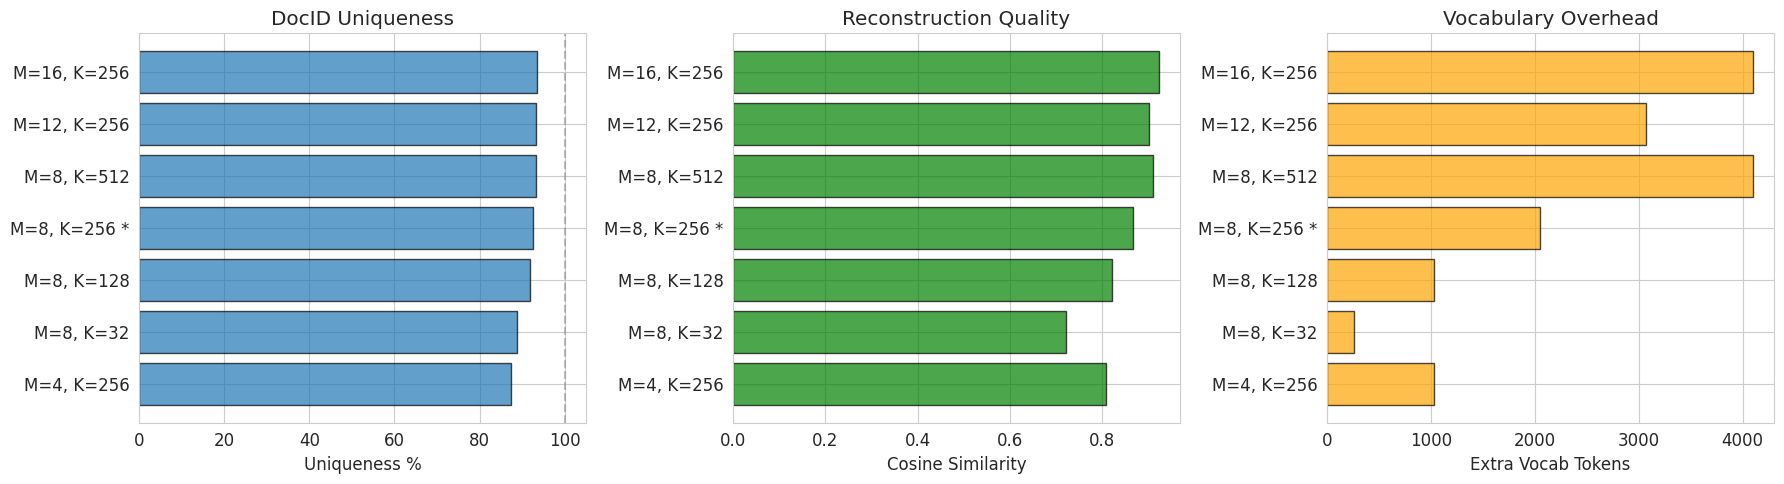

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(rdf['Config'], rdf['Unique%'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Uniqueness %')
axes[0].set_title('DocID Uniqueness')
axes[0].axvline(100, color='gray', linestyle='--', alpha=0.5)

axes[1].barh(rdf['Config'], rdf['CosSim'], alpha=0.7, edgecolor='black', color='green')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_title('Reconstruction Quality')

axes[2].barh(rdf['Config'], rdf['Vocab+'], alpha=0.7, edgecolor='black', color='orange')
axes[2].set_xlabel('Extra Vocab Tokens')
axes[2].set_title('Vocabulary Overhead')

plt.tight_layout()
plt.show()

## 14. T5 Decoder Demo

Show how the T5 decoder would process these DocIDs with the masked head.

In [28]:
t5_lm = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device).eval()

orig_vocab = t5_lm.config.vocab_size
new_vocab = orig_vocab + M * K
t5_lm.resize_token_embeddings(new_vocab)

print(f"Vocab: {orig_vocab} -> {new_vocab} (+{M * K} RQ tokens)")
print(f"LM head: {t5_lm.lm_head.weight.shape}")
print(f"New tokens are randomly initialized; training learns their embeddings.")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Vocab: 32128 -> 34176 (+2048 RQ tokens)
LM head: torch.Size([34176, 768])
New tokens are randomly initialized; training learns their embeddings.


In [29]:
# Masked head — valid token ranges per decoding step
print("Masked Head: valid token ranges per step")
print("=" * 55)
for i in range(M):
    lo = T5_VOCAB_SIZE + K * i
    hi = T5_VOCAB_SIZE + K * (i + 1) - 1
    print(f"Step {i}: [{lo:>6}, {hi:>6}] ({K} valid, {new_vocab - K} masked)")

Masked Head: valid token ranges per step
Step 0: [ 32100,  32355] (256 valid, 33920 masked)
Step 1: [ 32356,  32611] (256 valid, 33920 masked)
Step 2: [ 32612,  32867] (256 valid, 33920 masked)
Step 3: [ 32868,  33123] (256 valid, 33920 masked)
Step 4: [ 33124,  33379] (256 valid, 33920 masked)
Step 5: [ 33380,  33635] (256 valid, 33920 masked)
Step 6: [ 33636,  33891] (256 valid, 33920 masked)
Step 7: [ 33892,  34147] (256 valid, 33920 masked)


In [30]:
# Forward pass demo (untrained — just verifying the pipeline)
query = "What happened in the US election?"
inp = tokenizer(query, return_tensors="pt", max_length=64, truncation=True).to(device)

target = torch.tensor([smtids[0]], dtype=torch.long, device=device)
dec_in = torch.cat([
    torch.full((1, 1), tokenizer.pad_token_id, dtype=torch.long, device=device),
    target[:, :-1]
], dim=1)

print(f"Query: '{query}'")
print(f"Target SMTID:     {target[0].tolist()}")
print(f"Decoder input:    {dec_in[0].tolist()}")

with torch.no_grad():
    logits = t5_lm(input_ids=inp['input_ids'], attention_mask=inp['attention_mask'],
                   decoder_input_ids=dec_in).logits

print(f"Logits shape: {logits.shape}  (batch, seq_len={logits.shape[1]}, vocab={logits.shape[2]})")

print(f"\nTop-5 predictions per step (with codebook masking):")
for step in range(M):
    sl = logits[0, step].clone()
    mask = torch.ones(new_vocab, dtype=torch.bool, device=device)
    cb_lo = T5_VOCAB_SIZE + K * step
    mask[cb_lo:cb_lo + K] = False
    sl[mask] = float('-inf')
    probs = torch.softmax(sl, dim=-1)
    top5p, top5i = probs.topk(5)
    tgt = target[0, step].item()
    tgt_rank = int((probs.argsort(descending=True) == tgt).nonzero().item()) + 1
    print(f"  Step {step}: top codes={[t.item()-cb_lo for t in top5i]}, "
          f"target code={tgt - cb_lo} (rank {tgt_rank}/{K})")

Query: 'What happened in the US election?'
Target SMTID:     [32142, 32488, 32831, 32900, 33204, 33556, 33667, 33963]
Decoder input:    [0, 32142, 32488, 32831, 32900, 33204, 33556, 33667]


/tmp/ipykernel_27841/3253720335.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  target = torch.tensor([smtids[0]], dtype=torch.long, device=device)


Logits shape: torch.Size([1, 8, 34176])  (batch, seq_len=8, vocab=34176)

Top-5 predictions per step (with codebook masking):
  Step 0: top codes=[173, 59, 159, 104, 146], target code=42 (rank 75/256)
  Step 1: top codes=[122, 0, 162, 66, 49], target code=132 (rank 180/256)
  Step 2: top codes=[157, 51, 24, 84, 2], target code=219 (rank 90/256)
  Step 3: top codes=[162, 135, 242, 225, 37], target code=32 (rank 193/256)
  Step 4: top codes=[102, 149, 8, 205, 132], target code=80 (rank 61/256)
  Step 5: top codes=[146, 207, 201, 3, 175], target code=176 (rank 175/256)
  Step 6: top codes=[31, 89, 184, 145, 157], target code=31 (rank 1/256)
  Step 7: top codes=[191, 138, 81, 83, 183], target code=71 (rank 40/256)


In [31]:
del t5_lm
torch.cuda.empty_cache()

## 15. Save Artifacts

In [32]:
OUTPUT_DIR = f"../experiments/docid_poc_output_N{NUM_DOCS}_M{M}_K{K}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# DocID mapping
docid_to_smtid = {}
for i in range(len(df_sample)):
    key = df_sample.iloc[i].get('url', str(i))
    docid_to_smtid[key] = doc_codes[i].tolist()
with open(os.path.join(OUTPUT_DIR, "docid_to_smtid.json"), "w") as f:
    json.dump(docid_to_smtid, f)

np.save(os.path.join(OUTPUT_DIR, "doc_embeddings.npy"), doc_embeddings)
faiss.write_index(rq_index, os.path.join(OUTPUT_DIR, "rq_index.faiss"))
df_sample[['title', 'url', 'date', 'domain']].to_parquet(
    os.path.join(OUTPUT_DIR, "sample_metadata.parquet"))

# Save config for reproducibility
with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    json.dump({'NUM_DOCS': NUM_DOCS, 'M': M, 'NBITS': NBITS, 'K': K,
               'MODEL_NAME': MODEL_NAME, 'MAX_LENGTH': MAX_LENGTH, 'SEED': SEED}, f, indent=2)

print(f"Saved to {OUTPUT_DIR}/")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, fn))
    print(f"  {fn}: {sz/1e6:.1f} MB" if sz > 1e6 else f"  {fn}: {sz/1e3:.1f} KB")

Saved to ../experiments/docid_poc_output_N10000_M8_K256/
  config.json: 0.1 KB
  doc_embeddings.npy: 30.7 MB
  docid_to_smtid.json: 1.5 MB
  rq_index.faiss: 6.4 MB
  sample_metadata.parquet: 1.2 MB


## 16. Summary & Next Steps

In [33]:
print("=" * 55)
print("  DocID Generation POC — Summary")
print("=" * 55)
print(f"  Documents:            {n_total:>10,}")
print(f"  Encoder:              {MODEL_NAME:>10}")
print(f"  Embedding dim:        {doc_embeddings.shape[1]:>10}")
print(f"  RQ config:            M={M}, K={K} (nbits={NBITS})")
print(f"  DocID length:         {M:>10} tokens")
print(f"  Uniqueness:           {n_unique/n_total*100:>9.1f}%")
print(f"  Reconstruction cos:   {cos_sims.mean():>10.4f}")
print(f"  New vocab tokens:     {M * K:>10,}")
print(f"  Total vocab:          {T5_VOCAB_SIZE + M * K:>10,}")
print("=" * 55)
print()
print("Next steps:")
print("  1. Scale to full corpus (all CC-News + BBC News)")
print("  2. Train T5 seq2seq: query -> 8-token DocID")
print("  3. Implement Chrono-Semantic DocIDs ([Year]-[Month] prefix)")
print("  4. Continual learning on temporal splits")
print("  5. Measure Positive Forgetting Rate")

  DocID Generation POC — Summary
  Documents:                 9,992
  Encoder:                 t5-base
  Embedding dim:               768
  RQ config:            M=8, K=256 (nbits=8)
  DocID length:                  8 tokens
  Uniqueness:                92.7%
  Reconstruction cos:       0.8675
  New vocab tokens:          2,048
  Total vocab:              34,148

Next steps:
  1. Scale to full corpus (all CC-News + BBC News)
  2. Train T5 seq2seq: query -> 8-token DocID
  3. Implement Chrono-Semantic DocIDs ([Year]-[Month] prefix)
  4. Continual learning on temporal splits
  5. Measure Positive Forgetting Rate
